In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage # BaseMessage is flexible version of SystemMessage, AiMessage etc.
from langgraph.graph.message import add_messages # Used in-place of operator as it is more optimized to work with BaseMessage.

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model = 'llama-3.3-70b-versatile',
    temperature= 0
)

In [4]:
class ChatState(TypedDict):
    msgs : Annotated[list[BaseMessage], add_messages]

In [5]:
def chatting(state : ChatState):
    chat = state['msgs']
    msgs = model.invoke(chat)
    return {'msgs' : msgs}

In [6]:
graph = StateGraph(ChatState)

graph.add_node('chatting', chatting)

graph.add_edge(START, 'chatting')
graph.add_edge('chatting', END)

workflow = graph.compile()

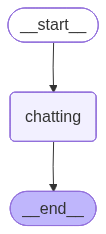

In [7]:
workflow

In [8]:
user_query = {
    'msgs' : [HumanMessage(content= 'What is the average weight of a men body have to be?')]
}

workflow.invoke(user_query)['msgs'][-1].content # This gives you plan string straight from llm.

"The average weight of a male body can vary depending on several factors such as age, height, and body composition. Here are some general guidelines:\n\n**For adult men:**\n\n* According to the World Health Organization (WHO), the average weight for an adult male is around 76 kg (167 lbs) for a height of 172 cm (5 ft 8 in).\n* The National Institutes of Health (NIH) suggests that a healthy weight for adult men is:\n\t+ For a small frame: 54-63 kg (119-139 lbs)\n\t+ For a medium frame: 63-72 kg (139-159 lbs)\n\t+ For a large frame: 72-81 kg (159-179 lbs)\n* The Body Mass Index (BMI) is another way to determine a healthy weight. For adult men, a healthy BMI is:\n\t+ Underweight: less than 18.5\n\t+ Normal weight: 18.5-24.9\n\t+ Overweight: 25-29.9\n\t+ Obese: 30 or higher\n\n**For different age groups:**\n\n* For young men (18-24 years): 64-75 kg (141-165 lbs)\n* For adult men (25-44 years): 72-84 kg (159-185 lbs)\n* For middle-aged men (45-64 years): 78-92 kg (172-203 lbs)\n* For older 

In [ ]:
chat_history = []  

while True:
    user_msgs = input('You: ')  

    if user_msgs.strip().lower() in ['quit', 'exit', 'bye']:
        break
    print(f'You: {user_msgs}')  

    chat_history.append(HumanMessage(content=user_msgs))  

    response = workflow.invoke({
        'msgs': chat_history  
    })

    ai_reply = response['msgs'][-1].content
    chat_history.append(response['msgs'][-1])  
    print('AI:', ai_reply)

AI: It's nice to meet you. Is there something I can help you with or would you like to chat?
AI: I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How about you? How's your day going?
AI: It seems like we just started our conversation, and I haven't shared anything with you yet. If you're ready to chat, I'd be happy to discuss something with you. What's on your mind?
